
## Dataset : Financial Sentiment Analysis
## Link : mltrev23/financial-sentiment-analysis

# Model 1: FinBert Pre-Trained

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, pipeline, AutoTokenizer,AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split

In [2]:
# tested in transformers==4.18.0
import transformers
transformers.__version__

'4.57.2'

**Load Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()  # This will open a file selector

Saving Fianancial_Sentiment_Analysis.csv to Fianancial_Sentiment_Analysis.csv


In [4]:
# Load the CSV file using pandas, specifying the correct encoding and letting it infer the delimiter (comma by default)
# The CSV has a header: 'Sentence,Sentiment'
df = pd.read_csv("/content/Fianancial_Sentiment_Analysis.csv", encoding="iso-8859-1")

# Rename columns to match the expected 'sentence' and 'label' as used in the original code
df.rename(columns={'Sentence': 'sentence', 'Sentiment': 'label'}, inplace=True)

# Map string labels to numerical values
df["label"] = df["label"].map({
    "positive":0,
    "negative":1,
    "neutral": 2
})

df.head()

,sentence,label
0,The GeoSolutions technology will leverage Bene...,0
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",1
2,"For the last quarter of 2010 , Componenta 's n...",0
3,According to the Finnish-Russian Chamber of Co...,2
4,The Swedish buyout firm has sold its remaining...,2


**Load Pre-trained FinBert model**

In [5]:
finbert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone',num_labels=3)
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [6]:
nlp = pipeline("text-classification", model=finbert, tokenizer=tokenizer)
results = nlp(df["sentence"].to_list())

Device set to use cpu


**Confusion Matrix + Classification Report**

In [7]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negative", "neutral", "positive"], yticklabels=["negative", "neutral", "positive"])
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

FinBERT Accuracy: 0.6951386511468675
              precision    recall  f1-score   support

    positive       0.87      0.53      0.66      1852
     neutral       0.50      0.61      0.55       860
    negative       0.70      0.82      0.75      3130

    accuracy                           0.70      5842
   macro avg       0.69      0.65      0.65      5842
weighted avg       0.72      0.70      0.69      5842



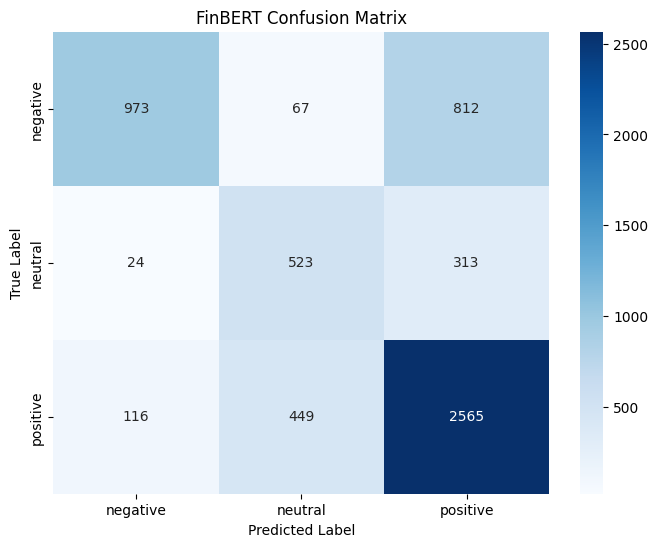

In [10]:
predicted_labels_str = [r['label'] for r in results]
# Update label_mapping to match the actual output from the FinBERT pipeline
# and align with the dataset's numerical labels: 0 for positive, 1 for negative, 2 for neutral.
label_mapping = {
    "Positive": 0, # Maps 'Positive' from pipeline to 0 (positive) in df["label"]
    "Negative": 1, # Maps 'Negative' from pipeline to 1 (negative) in df["label"]
    "Neutral": 2   # Maps 'Neutral' from pipeline to 2 (neutral) in df["label"]
}

mapped_predicted_labels_pretrained = [label_mapping[label] for label in predicted_labels_str]

print("FinBERT Accuracy:", accuracy_score(df["label"], mapped_predicted_labels_pretrained))
print(classification_report(df["label"], mapped_predicted_labels_pretrained, target_names=["positive","neutral","negative"]))
plot_confusion_matrix(df["label"], mapped_predicted_labels_pretrained, "FinBERT Confusion Matrix")

#Model 2: FinBert Fine-Tuned

**Load Fine-tuned FinBert Model**

In [ ]:
finbert_phrasebank = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/finbert_sentiment_saved',num_labels=3)
tokenizer_phrasebank = BertTokenizer.from_pretrained('/content/drive/MyDrive/finbert_sentiment_saved/')

In [ ]:
#tokenizer_phrasebank = BertTokenizer.from_pretrained('/content/drive/MyDrive/finbert_sentiment_saved/')
nlp = pipeline("text-classification", model=finbert_phrasebank, tokenizer=tokenizer_phrasebank)
results = nlp(df["sentence"].to_list())

Device set to use cpu


**Confusion Matrix + Classification Report**

FinBERT Accuracy: 0.7293735022252653
              precision    recall  f1-score   support

    positive       0.86      0.65      0.74      1852
    negative       0.52      0.62      0.56       860
     neutral       0.74      0.81      0.77      3130

    accuracy                           0.73      5842
   macro avg       0.70      0.69      0.69      5842
weighted avg       0.74      0.73      0.73      5842



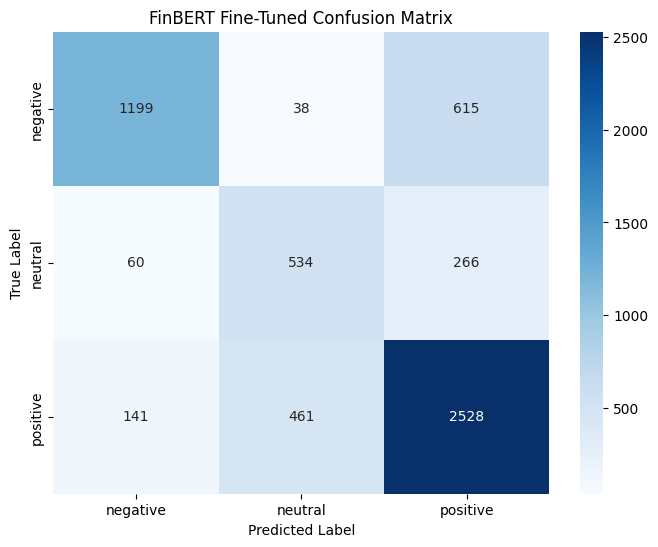

In [ ]:
predicted_labels_fin = [r['label'] for r in results]
label_mapping_fin = {
    "Positive": 1,
    "Negative": 2,
    "Neutral": 0
}

mapped_predicted_labels_fin = [label_mapping_fin[label] for label in predicted_labels_fin]

print("FinBERT Accuracy:", accuracy_score(df["label"], mapped_predicted_labels_fin))
print(classification_report(df["label"], mapped_predicted_labels_fin, target_names=["positive","negative","neutral"]))
plot_confusion_matrix(df["label"], mapped_predicted_labels_fin, "FinBERT Fine-Tuned Confusion Matrix")

# Model 3: Bert Base Pre-trained

**Load Pre-trained Bert Model**

In [ ]:
bert_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_name, num_labels=3)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
nlp = pipeline("text-classification", model=bert_model, tokenizer=bert_tokenizer)
bert_results = nlp(df["sentence"].to_list())

Device set to use cpu


**Confusion Matrix + Classification Report**

BERT Accuracy: 0.5236220472440944
              precision    recall  f1-score   support

    positive       0.00      0.00      0.00      1852
    negative       0.15      0.03      0.05       860
     neutral       0.54      0.97      0.69      3130

    accuracy                           0.52      5842
   macro avg       0.23      0.33      0.25      5842
weighted avg       0.31      0.52      0.38      5842



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


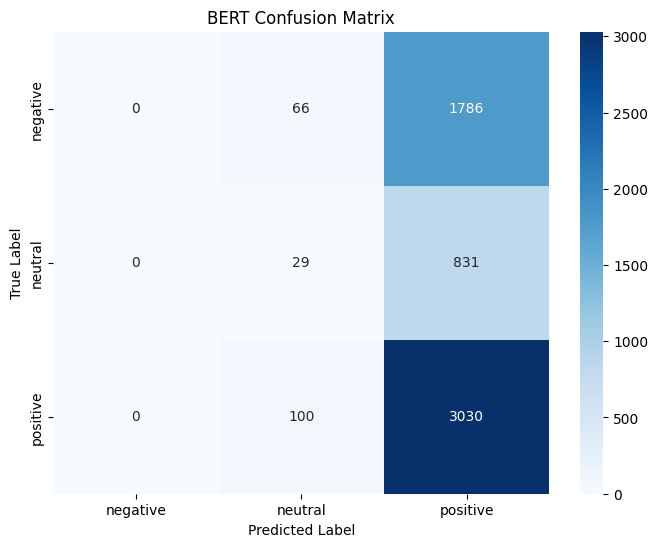

In [ ]:
predicted_labels_bert = [r['label'] for r in bert_results]
# Updated label_mapping to match BERT pipeline outputs and dataset labels
label_mapping = {
    "LABEL_0": 0, # Assuming LABEL_0 corresponds to positive (0)
    "LABEL_1": 1, # Assuming LABEL_1 corresponds to negative (1)
    "LABEL_2": 2  # Assuming LABEL_2 corresponds to neutral (2)
}

mapped_predicted_labels = [label_mapping[label] for label in predicted_labels_bert]

print("BERT Accuracy:", accuracy_score(df["label"], mapped_predicted_labels))
print(classification_report(df["label"], mapped_predicted_labels, target_names=["positive","negative","neutral"]))
plot_confusion_matrix(df["label"], mapped_predicted_labels, "BERT Confusion Matrix")

# Model 4: Bert Base Fine-Tuned

**Load Fine-tuned Bert Model**

In [ ]:
bert_phrasebank = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/bert_model_saved',num_labels=3)
bert_tokenizer_phrasebank = BertTokenizer.from_pretrained('/content/drive/MyDrive/bert_model_saved/')

In [ ]:
nlp = pipeline("text-classification", model=bert_phrasebank , tokenizer=bert_tokenizer_phrasebank)
bert_model_results = nlp(df["sentence"].to_list())

Device set to use cpu


**Confusion Matrix + Classification Report**

BERT Accuracy: 0.5386853817185895
              precision    recall  f1-score   support

    positive       0.37      0.31      0.34      1852
    negative       1.00      0.00      0.00       860
     neutral       0.60      0.82      0.69      3130

    accuracy                           0.54      5842
   macro avg       0.66      0.38      0.34      5842
weighted avg       0.59      0.54      0.48      5842



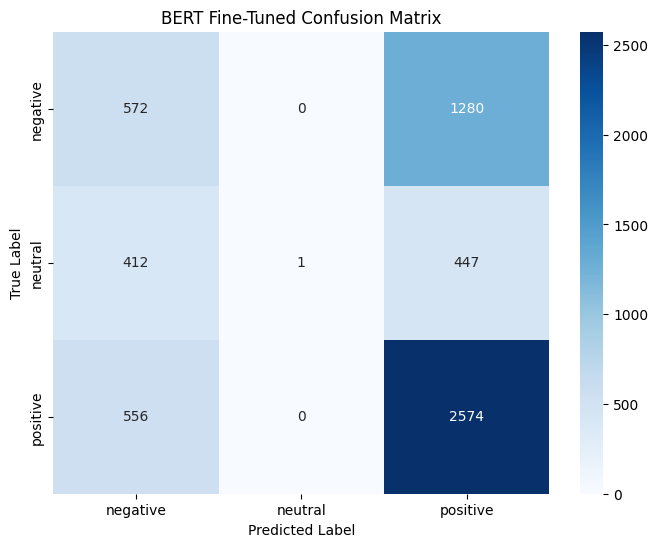

In [ ]:
predicted_labels_Bert = [r['label'] for r in bert_model_results]
# Updated label_mapping to match BERT pipeline outputs and dataset labels
label_mapping_bert = {
    "LABEL_0": 0, # Assuming LABEL_0 corresponds to positive (0)
    "LABEL_1": 1, # Assuming LABEL_1 corresponds to negative (1)
    "LABEL_2": 2  # Assuming LABEL_2 corresponds to neutral (2)
}

mapped_predicted_labels_Bert = [label_mapping_bert[label] for label in predicted_labels_Bert]

print("BERT Accuracy:", accuracy_score(df["label"], mapped_predicted_labels_Bert))
print(classification_report(df["label"], mapped_predicted_labels_Bert, target_names=["positive","negative","neutral"]))
plot_confusion_matrix(df["label"], mapped_predicted_labels_Bert, "BERT Fine-Tuned Confusion Matrix")

# Model 5: ULMfit

epoch,train_loss,valid_loss,accuracy,time
0,0.967439,0.776721,0.647260,03:09


epoch,train_loss,valid_loss,accuracy,time
0,0.820981,0.734968,0.679795,06:56


ULMFiT Accuracy: 0.6797945205479452
              precision    recall  f1-score   support

    negative       0.64      0.55      0.59       366
     neutral       0.45      0.36      0.40       171
    positive       0.74      0.84      0.79       631

    accuracy                           0.68      1168
   macro avg       0.61      0.58      0.59      1168
weighted avg       0.67      0.68      0.67      1168



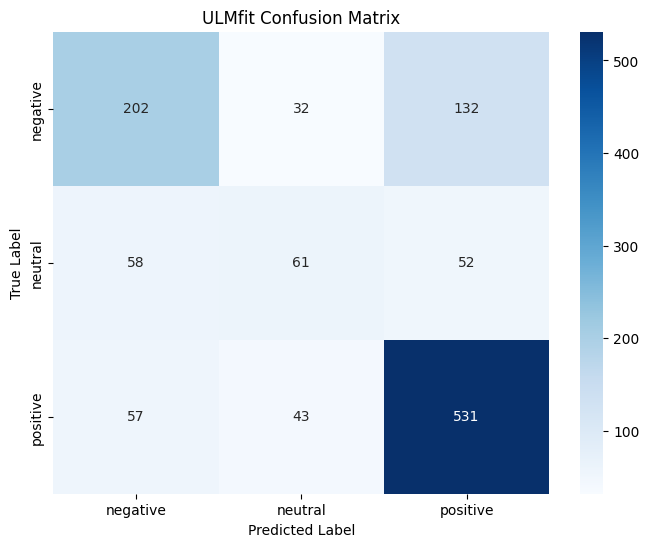

In [11]:
from fastai.text.all import *

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

dls = TextDataLoaders.from_df(
    pd.concat([train_df, test_df]),
    text_col='sentence',
    label_col='label',
    valid_pct=0.2,
    text_vocab=None
)

learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(1)

ulm_preds, ulm_true = learn.get_preds()
ulm_y_pred = ulm_preds.argmax(dim=1)

print("ULMFiT Accuracy:", accuracy_score(ulm_true, ulm_y_pred))
print(classification_report(ulm_true, ulm_y_pred, target_names=["negative","neutral","positive"]))
plot_confusion_matrix(ulm_true, ulm_y_pred, "ULMfit Confusion Matrix")

# Model 6 : Roberta Pre-trained

**Load RoBerta Pre-trained model**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

roberta_name = "cardiffnlp/twitter-roberta-base-sentiment"
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_name)
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_name)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
nlp = pipeline(
    "text-classification",
    model=roberta_model,
    tokenizer=roberta_tokenizer,
    return_all_scores=False
)

Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
results = nlp(df["sentence"].to_list())

In [ ]:
# Model output labels: LABEL_0, LABEL_1, LABEL_2
predicted_labels_str = [r["label"] for r in results]

In [ ]:
# Map RoBERTa Labels
# ------------------------------
roberta_label_map = {
    "LABEL_2": 0,   # positive
    "LABEL_0": 1,   # negative
    "LABEL_1": 2    # neutral
}

mapped_predicted_labels_roberta = [roberta_label_map[label] for label in predicted_labels_str]

**Confusion Matrix + Classification Report**

RoBERTa Accuracy: 0.6353988360150633
              precision    recall  f1-score   support

    negative       0.75      0.39      0.51      1852
     neutral       0.58      0.33      0.42       860
    positive       0.62      0.87      0.72      3130

    accuracy                           0.64      5842
   macro avg       0.65      0.53      0.55      5842
weighted avg       0.65      0.64      0.61      5842



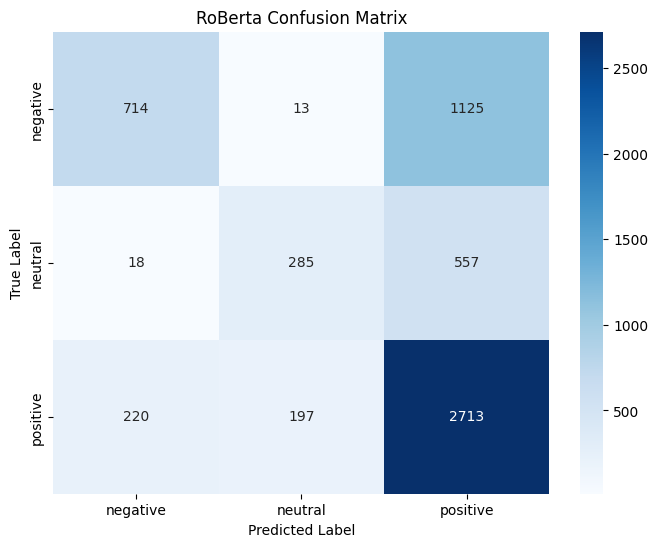

In [ ]:
# Compute Accuracy
# ------------------------------
print("RoBERTa Accuracy:", accuracy_score(df["label"], mapped_predicted_labels_roberta))

print(classification_report(
    df["label"],
    mapped_predicted_labels_roberta,
    target_names=["negative", "neutral","positive"]
))
plot_confusion_matrix(df["label"],mapped_predicted_labels_roberta, "RoBerta Confusion Matrix")


# Comparison Graph for All Models

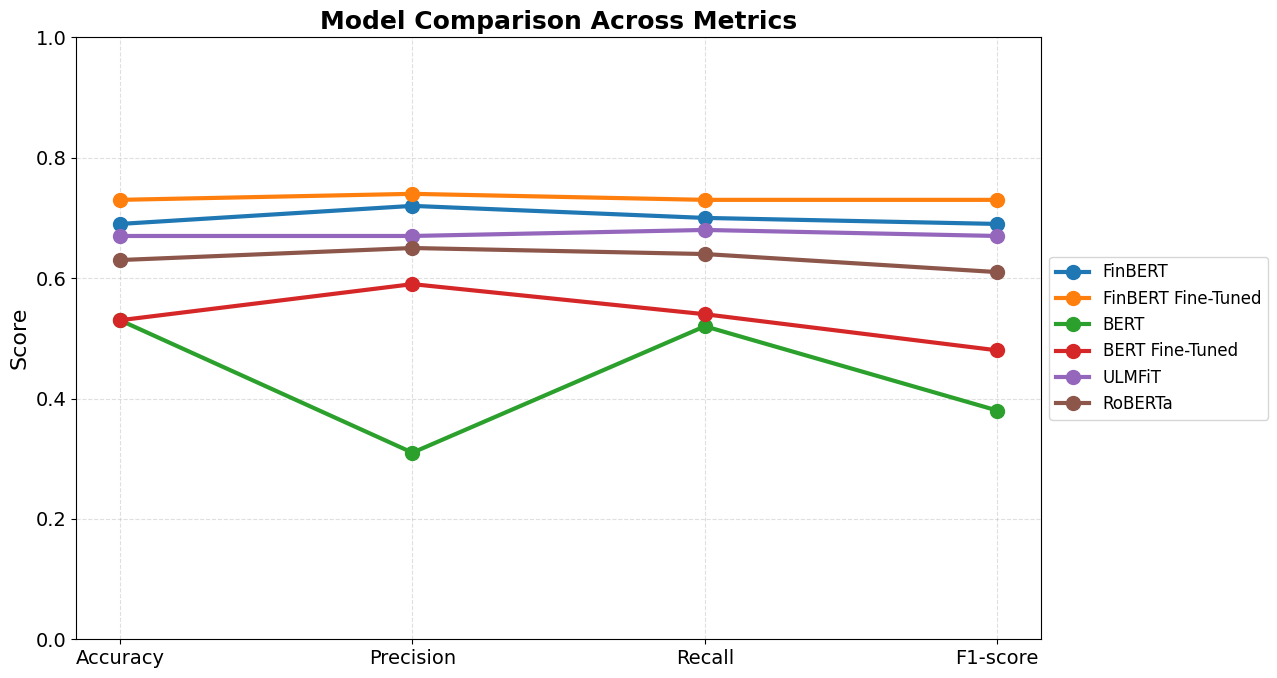

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams.update({'font.size': 14})

# Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

Finbert = [0.69, 0.72, 0.70, 0.69]
Finbert_Fine_Tune = [0.73, 0.74, 0.73, 0.73]
Bert = [0.53, 0.31, 0.52, 0.38]
Bert_Fine_Tune = [0.53, 0.59, 0.54, 0.48]
Ulmfit = [0.67, 0.67, 0.68, 0.67]
RoBERTa = [0.63, 0.65, 0.64, 0.61]

# Color palette
colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b"   # brown
]

plt.figure(figsize=(13, 7))

# Plot
plt.plot(metrics, Finbert, marker='o', markersize=10, linewidth=3, color=colors[0], label="FinBERT")
plt.plot(metrics, Finbert_Fine_Tune, marker='o', markersize=10, linewidth=3, color=colors[1], label="FinBERT Fine-Tuned")
plt.plot(metrics, Bert, marker='o', markersize=10, linewidth=3, color=colors[2], label="BERT")
plt.plot(metrics, Bert_Fine_Tune, marker='o', markersize=10, linewidth=3, color=colors[3], label="BERT Fine-Tuned")
plt.plot(metrics, Ulmfit, marker='o', markersize=10, linewidth=3, color=colors[4], label="ULMFiT")
plt.plot(metrics, RoBERTa, marker='o', markersize=10, linewidth=3, color=colors[5], label="RoBERTa")

plt.title("Model Comparison Across Metrics", fontsize=18, weight='bold')
plt.ylabel("Score", fontsize=16)
plt.ylim(0, 1)

# Rotated labels
plt.xticks(metrics, rotation=0, fontsize=14)

plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

plt.tight_layout()
plt.show()
